## 1. Load the Trained Cat vs Dog Model

In this notebook, we will use the CNN model that was trained and saved in the training notebook.

We will not train the model again.

The saved model will be loaded and used to classify completely new images as either **Cat** or **Dog**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array

## 2. Load the Saved Model

The trained CNN model was saved in the `models` directory as a `.keras` file.

We load this model so that it can be used for prediction without repeating the training process.

In [2]:
# Path to the saved model
model_path = "../models/dog_cat_classifier.keras"

# Load the trained model
model = load_model(model_path)

print("Model loaded successfully!")

Model loaded successfully!


## 3. Select a New Image

We will now select an image that the trained CNN has never seen before.

The image should be placed inside the `data/raw/new_images/` directory.

This allows us to test whether the saved model can classify a completely new image.

In [8]:
# Select a random image
import random
# Directory containing new images
new_images_dir = Path("../data/raw/new_images")

# Find image files
image_paths = (
    list(new_images_dir.glob("*.jpg")) +
    list(new_images_dir.glob("*.jpeg")) +
    list(new_images_dir.glob("*.png"))
)

# Check whether images are available
if not image_paths:
    raise FileNotFoundError(
        "No images found in data/raw/new_images/"
    )

# Select the first image
image_path = random.choice(image_paths)

print("Selected image:", image_path)


Selected image: ..\data\raw\new_images\images (10).jpeg


## 4. Display the New Image

Before making a prediction, we display the selected image.

This allows us to visually inspect the image that will be given to the CNN.

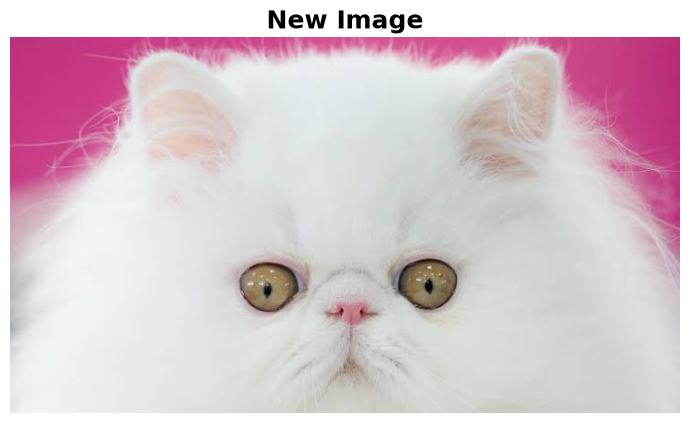

In [9]:
# Load the image for display
image = load_img(image_path)

plt.figure(figsize=(7, 7))

plt.imshow(image)

plt.title(
    "New Image",
    fontsize=18,
    fontweight="bold"
)

plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Preprocess the Image

The new image must be preprocessed in the same way as the images used during training.

The image will be:

1. Resized to 256 × 256 pixels.
2. Converted into a numerical array.
3. Normalized so that pixel values are between 0 and 1.
4. Expanded with a batch dimension so it can be passed to the CNN.

In [10]:
# Resize the image
image_resized = load_img(
    image_path,
    target_size=(256, 256)
)

# Convert image to NumPy array
image_array = img_to_array(image_resized)

# Normalize pixel values
image_array = image_array / 255.0

# Add batch dimension
image_array = np.expand_dims(
    image_array,
    axis=0
)

print("Image shape:", image_array.shape)

Image shape: (1, 256, 256, 3)


## 6. Make the Prediction

The preprocessed image is passed to the saved CNN model.

Since this is a binary classification problem, the model produces a probability between 0 and 1.

- Probability < 0.5 → Cat
- Probability ≥ 0.5 → Dog

In [11]:
# Make prediction
prediction = model.predict(
    image_array,
    verbose=0
)

# Extract probability
probability = prediction[0][0]

# Determine predicted class
if probability >= 0.5:
    predicted_class = "Dog"
    confidence = probability
else:
    predicted_class = "Cat"
    confidence = 1 - probability

print("Predicted class:", predicted_class)
print("Confidence:", f"{confidence:.2%}")

Predicted class: Cat
Confidence: 54.61%


## 7. Display the Final Prediction

The final result is displayed together with the predicted class and confidence score.

This gives us a simple visual demonstration of the CNN's prediction on a completely new image.

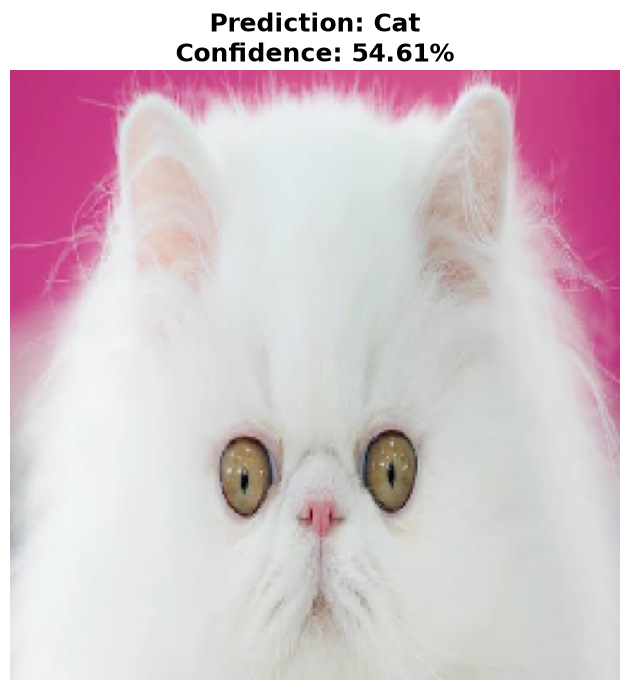

In [12]:
plt.figure(figsize=(7, 7))

plt.imshow(image_resized)

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2%}",
    fontsize=18,
    fontweight="bold"
)

plt.axis("off")

plt.tight_layout()
plt.show()